# Oracle extrapolation — cross-cluster cross-validation (70% & 85% identity)

This drops the coordinated surrogate/oracle *dual* split and focuses on the **oracle** model alone
(`cnn-concatstd-d1`, unchanged architecture/loss/hyperparameters). Instead of one train/val/test
split — whose cluster-based test MAE we saw is a noisy point estimate — we measure the oracle's
**extrapolation to unseen sequence families** with proper **grouped (cross-cluster) K-fold CV**:

* **Interpolation baseline** — ordinary 5-fold CV (`KFold`, shuffled). Homologs of a test protein can
  sit in training, so this is the *optimistic* regime.
* **Extrapolation @70%** — 5-fold `GroupKFold` with groups = 70%-identity clusters. Every fold holds
  out whole clusters, so no test protein has a ≥70%-identity homolog in training.
* **Extrapolation @85%** — same, with 85%-identity clusters (only near-duplicates removed from
  training).

Grouped K-fold gives **out-of-fold (OOF) predictions for every protein** from a model that never saw
its cluster, so we get (a) a robust pooled MAE, (b) fold-to-fold mean ± std, and (c) a per-cluster
extrapolation breakdown — all without touching any existing weight, notebook, or `peak_models.py`.

> Heavy training is cached per fold in `oracle_cv_cache/`; re-running reads the cache instantly.
> Delete that folder to recompute from scratch. Uses `seqid70_clusters.csv` / `seqid85_clusters.csv`
> (from the split notebooks); if absent, it re-derives the clusters inline.


## 0. Setup — data, ESM-2 cache, oracle spec

In [1]:
import csv, os, time, numpy as np, torch
import peak_models as pm
from sklearn.model_selection import GroupKFold, KFold, GroupShuffleSplit
try:
    import arcadia_pycolor as apc; apc.mpl.setup(); HAVE_APC=True
except Exception:
    HAVE_APC=False
import matplotlib.pyplot as plt
class _C:
    def __getattr__(self,k): return getattr(apc,k) if HAVE_APC else {"aegean":"#2b6c8f","amber":"#f6a200","rose":"#c5474b","seaweed":"#3b8a6e","gray":"#888888","wish":"#5088c5","aster":"#7a5ea8","dragon":"#c85152","lime":"#97cd3f"}.get(k,"#333333")
apc_c=_C()

CUR="../dataset_pipeline/data/peak/curated"; CACHE="oracle_cv_cache"; os.makedirs(CACHE,exist_ok=True)
dev=torch.device("mps") if (getattr(torch.backends,"mps",None) and torch.backends.mps.is_available()) \
    else (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
rows=list(csv.DictReader(open(os.path.join(CUR,"peaks_assignments.csv")))); N=len(rows)
names=[r["name"] for r in rows]
peaks=np.load(os.path.join(CUR,"peaks.npy")).astype(np.float32)
seqs=[None]*N; h=None
for line in open(os.path.join(CUR,"sequences.fasta")):
    line=line.strip()
    if line.startswith(">"): h=int(line[1:].split("|")[0])
    elif line: seqs[h]=line
H=np.load(os.path.join(CUR,"esm_residue_fp16.npy")); Ls=np.load(os.path.join(CUR,"esm_residue_len.npy"))
Lmax=int(Ls.max()); H=H[:,:Lmax]; Ht=torch.tensor(H); ar=torch.arange(Lmax)
Pk=torch.tensor(peaks, dtype=torch.float32, device=dev)

# Oracle = the exact model the pipeline uses; only the evaluation protocol changes here.
ORACLE_SPEC=dict(arch="cnn", pool="concatstd", conv_ch=128, k=5, n_conv=1, hidden=256, nl=2, sid="cnn-concatstd-d1")
EPOCHS=150; LR=1e-3; WD=1e-4; DROP=0.2; NSPLITS=5; SEED=0
def batches(idx,bs=32,shuffle=False):
    idx=np.array(idx)
    if shuffle: np.random.shuffle(idx)
    for i in range(0,len(idx),bs):
        b=idx[i:i+bs]
        yield Ht[b].float().to(dev),(ar.unsqueeze(0)<torch.tensor(Ls[b]).unsqueeze(1)).to(dev),b
print("device",dev,"| N",N,"| oracle =",ORACLE_SPEC["sid"])


device mps | N 758 | oracle = cnn-concatstd-d1


## 1. Sequence-identity clusters (groups for CV)

Loaded from the CSVs written by the split notebooks; re-derived inline (BLOSUM62 global alignment,
identity = identical residues / shorter length, single-linkage) if a CSV is missing.

In [2]:
def cluster_at(THR):
    from Bio.Align import PairwiseAligner, substitution_matrices
    al=PairwiseAligner(); al.substitution_matrix=substitution_matrices.load("BLOSUM62")
    al.open_gap_score=-11; al.extend_gap_score=-1; al.mode="global"
    L=np.array([len(s) for s in seqs]); K=5; PRE=0.30
    km=[frozenset(s[i:i+K] for i in range(len(s)-K+1)) for s in seqs]
    par=list(range(N))
    def find(x):
        while par[x]!=x: par[x]=par[par[x]]; x=par[x]
        return x
    for i in range(N):
        for j in range(i+1,N):
            mn=min(len(km[i]),len(km[j]))
            if mn==0 or len(km[i]&km[j])/mn<PRE: continue
            if al.align(seqs[i],seqs[j])[0].counts().identities/min(L[i],L[j])>=THR:
                ri,rj=find(i),find(j);
                if ri!=rj: par[ri]=rj
    comp={}
    for i in range(N): comp.setdefault(find(i),[]).append(i)
    clab=np.empty(N,int)
    for cid,m in enumerate(sorted(comp.values(),key=len,reverse=True)):
        for i in m: clab[i]=cid
    return clab
def load_clusters(pct, thr):
    p=os.path.join(CUR,f"seqid{pct}_clusters.csv")
    if os.path.exists(p):
        r=sorted(csv.DictReader(open(p)),key=lambda x:int(x["index"]))
        return np.array([int(x["cluster_id"]) for x in r])
    print(f"{p} missing — clustering inline @ {thr}"); return cluster_at(thr)
clab70=load_clusters(70,0.70); clab85=load_clusters(85,0.85)
for tag,cl in [("70%",clab70),("85%",clab85)]:
    s=np.bincount(cl); print(f"{tag}: {len(s)} clusters | largest {s.max()} ({100*s.max()/N:.0f}%) | top8 {sorted(s)[::-1][:8]}")


70%: 57 clusters | largest 273 (36%) | top8 [273, 113, 100, 83, 17, 16, 13, 10]
85%: 93 clusters | largest 254 (34%) | top8 [254, 99, 62, 37, 30, 20, 16, 16]


## 2. CV engine (grouped / random), with per-fold caching  *(oracle training identical to the pipeline)*

In [3]:
def predict(net, idx):
    net.eval(); ps=[]
    with torch.no_grad():
        for Hb,mk,b in batches(idx): ps.append(net(Hb,mk).cpu().numpy())
    return np.concatenate(ps)
def _mae(P,T): return 0.5*(np.abs(P[:,0]-T[:,0]).mean()+np.abs(P[:,1]-T[:,1]).mean())
def _r2(t,p):
    ss=((t-t.mean())**2).sum(); return 1-((t-p)**2).sum()/ss if ss>0 else float("nan")
def metrics(P,T):
    return dict(mae=float(_mae(P,T)), ex_mae=float(np.abs(P[:,0]-T[:,0]).mean()),
                em_mae=float(np.abs(P[:,1]-T[:,1]).mean()), r2_ex=float(_r2(T[:,0],P[:,0])), r2_em=float(_r2(T[:,1],P[:,1])))

def train_oracle(tr, va, seed=0):
    torch.manual_seed(seed); np.random.seed(seed)
    mean=peaks[tr].mean(0).astype("float32"); std=(peaks[tr].std(0)+1e-6).astype("float32")
    net=pm.wrap(pm.build_base(ORACLE_SPEC, dev, drop=DROP), mean, std, dev)
    sd=torch.tensor(std,device=dev); opt=torch.optim.Adam(net.parameters(),LR,weight_decay=WD); best=1e9; bst=None
    for ep in range(EPOCHS):
        net.train()
        for Hb,mk,b in batches(tr,shuffle=True):
            opt.zero_grad(); pred=net(Hb,mk); tgt=Pk[torch.as_tensor(b,device=dev)]
            loss=(((pred-tgt)/sd)**2).mean(); loss.backward(); opt.step()
        v=_mae(predict(net,va),peaks[va])
        if v<best: best=v; bst={k:vv.cpu().clone() for k,vv in net.base.state_dict().items()}
    net.base.load_state_dict(bst); return net

def inner_val(train_idx, groups, fold):
    if groups is None:
        rng=np.random.default_rng(SEED+fold); perm=rng.permutation(train_idx)
        nv=int(round(0.15*len(train_idx))); return perm[nv:], perm[:nv]
    tri,vai=next(GroupShuffleSplit(1,test_size=0.15,random_state=SEED).split(train_idx,groups=groups[train_idx]))
    return train_idx[tri], train_idx[vai]

def run_cv(scheme, groups):
    idx=np.arange(N)
    splits=(KFold(NSPLITS,shuffle=True,random_state=SEED).split(idx) if groups is None
            else GroupKFold(NSPLITS).split(idx,groups=groups))
    oof=np.full((N,2),np.nan,np.float32); foldid=np.full(N,-1,int)
    for k,(tr_idx,te_idx) in enumerate(splits):
        fc=os.path.join(CACHE,f"fold_{scheme}_{k}.npz")
        if os.path.exists(fc):
            d=np.load(fc); oof[d["test_idx"]]=d["pred"]; foldid[d["test_idx"]]=k; continue
        tr,va=inner_val(tr_idx,groups,k); t0=time.time(); net=train_oracle(tr,va,SEED)
        pred=predict(net,te_idx); oof[te_idx]=pred; foldid[te_idx]=k
        np.savez(fc,test_idx=te_idx,pred=pred)
        print(f"[{scheme}] fold {k}: n_te={len(te_idx)} test MAE {_mae(pred,peaks[te_idx]):.1f} nm ({time.time()-t0:.0f}s)")
    return oof, foldid
print("CV engine ready (EPOCHS=%d, folds=%d)"%(EPOCHS,NSPLITS))


CV engine ready (EPOCHS=150, folds=5)


## 3. Run the three CV schemes  *(reads `oracle_cv_cache/` if present; else trains 5 folds each)*

In [4]:
oof_rand, fid_rand = run_cv("random",  None)
oof_g70,  fid_g70  = run_cv("group70", clab70)
oof_g85,  fid_g85  = run_cv("group85", clab85)
SCHEMES=[("interpolation (random 5-fold)", oof_rand, fid_rand, None),
         ("extrapolation @70% (cross-cluster)", oof_g70, fid_g70, clab70),
         ("extrapolation @85% (cross-cluster)", oof_g85, fid_g85, clab85)]
print("done — OOF predictions for all", N, "proteins under each scheme")


done — OOF predictions for all 758 proteins under each scheme


## 4. Summary — pooled MAE, fold-to-fold spread, R²

In [5]:
def fold_maes(oof,fid):
    return np.array([_mae(oof[fid==k],peaks[fid==k]) for k in sorted(set(fid[fid>=0]))])
def boot_ci(oof, B=3000, seed=0):
    e=0.5*(np.abs(oof[:,0]-peaks[:,0])+np.abs(oof[:,1]-peaks[:,1]))
    r=np.random.default_rng(seed); bs=np.median(e[r.integers(0,len(e),(B,len(e)))],axis=1)
    return float(np.median(e)), float(np.percentile(bs,2.5)), float(np.percentile(bs,97.5))
print(f"{'scheme':36s} {'pooled MAE':>10} {'fold mean±std':>16} {'median[95%CI]':>20} {'R2_ex':>6} {'R2_em':>6}")
summary={}
for name,oof,fid,_ in SCHEMES:
    m=metrics(oof,peaks); fm=fold_maes(oof,fid); med,lo,hi=boot_ci(oof)
    summary[name]=dict(m=m, fold_mean=float(fm.mean()), fold_std=float(fm.std()), med=med, lo=lo, hi=hi)
    print(f"{name:36s} {m['mae']:9.1f}  {fm.mean():6.1f} ± {fm.std():4.1f}    {med:5.1f} [{lo:4.1f},{hi:5.1f}]  {m['r2_ex']:6.2f} {m['r2_em']:6.2f}")


scheme                               pooled MAE    fold mean±std        median[95%CI]  R2_ex  R2_em
interpolation (random 5-fold)             14.4    14.4 ±  1.4      6.7 [ 5.9,  7.4]    0.67   0.80
extrapolation @70% (cross-cluster)        29.7    29.4 ±  6.0     20.6 [18.8, 22.6]    0.30   0.56
extrapolation @85% (cross-cluster)        26.9    26.1 ±  3.9     23.7 [22.4, 24.9]    0.44   0.64


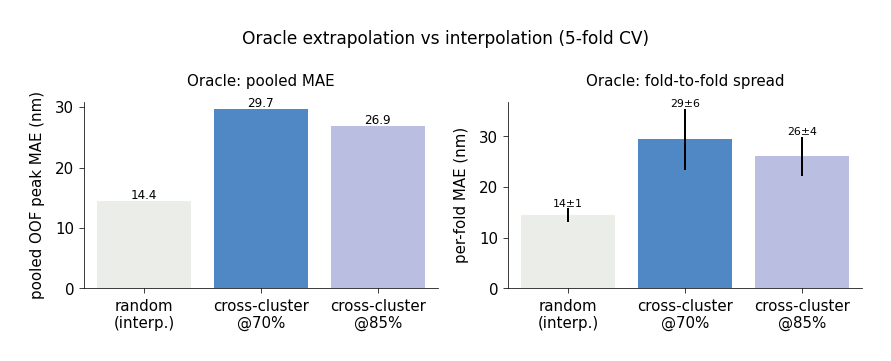

In [6]:
fig,ax=plt.subplots(1,2,figsize=(12,4.5))
labels=["random\n(interp.)","cross-cluster\n@70%","cross-cluster\n@85%"]
cols=[apc_c.gray, apc_c.aegean, apc_c.wish]
pooled=[summary[s[0]]["m"]["mae"] for s in SCHEMES]
fmean=[summary[s[0]]["fold_mean"] for s in SCHEMES]; fstd=[summary[s[0]]["fold_std"] for s in SCHEMES]
b=ax[0].bar(labels,pooled,color=cols)
for r,v in zip(b,pooled): ax[0].text(r.get_x()+r.get_width()/2,v+0.4,f"{v:.1f}",ha="center",fontsize=12)
ax[0].set_ylabel("pooled OOF peak MAE (nm)"); ax[0].set_title("Oracle: pooled MAE")
ax[1].bar(labels,fmean,yerr=fstd,color=cols,capsize=5)
for i,(m_,s_) in enumerate(zip(fmean,fstd)): ax[1].text(i,m_+s_+0.4,f"{m_:.0f}±{s_:.0f}",ha="center",fontsize=11)
ax[1].set_ylabel("per-fold MAE (nm)"); ax[1].set_title("Oracle: fold-to-fold spread")
plt.suptitle("Oracle extrapolation vs interpolation (5-fold CV)"); plt.tight_layout(); plt.show()


## 5. Per-cluster extrapolation

Each protein's OOF prediction under a grouped scheme comes from a model that never saw **any** member
of its cluster, so the per-cluster OOF MAE is a clean "how well does the oracle predict this unseen
lineage" number. Shown for the larger clusters (n ≥ 10).

In [7]:
def per_cluster(oof, clab, min_n=10):
    out=[]
    for cid in sorted(set(clab)):
        idx=np.where(clab==cid)[0]
        if len(idx)<min_n: continue
        ex=names[idx[0]]
        out.append((cid,len(idx),_mae(oof[idx],peaks[idx]),float(peaks[idx,1].mean()),ex))
    return sorted(out,key=lambda x:-x[1])
for tag,oof,clab in [("@70%",oof_g70,clab70),("@85%",oof_g85,clab85)]:
    print(f"\n=== extrapolation {tag} — per-cluster OOF MAE (n>=10) ===")
    print(f"{'cluster':>7} {'n':>4} {'MAE(nm)':>8} {'mean em':>8}  example member")
    for cid,n,mae,emm,ex in per_cluster(oof,clab):
        print(f"{cid:>7} {n:>4} {mae:8.1f} {emm:8.0f}  {ex}")



=== extrapolation @70% — per-cluster OOF MAE (n>=10) ===
cluster    n  MAE(nm)  mean em  example member
      0  273     30.9      503  10B
      1  113     17.9      514  afCFP
      2  100     36.4      590  BDFP2.0
      3   83     38.9      608  Bluebonnet2
      4   17     17.8      502  aacuGFP1
      5   16      6.8      506  CU17S
      6   13     47.4      556  AdRed
      7   10     67.0      548  HcRed

=== extrapolation @85% — per-cluster OOF MAE (n>=10) ===
cluster    n  MAE(nm)  mean em  example member
      0  254     30.6      503  10B
      1   99     30.4      590  BDFP2.0
      2   62     29.9      612  Bluebonnet2
      3   37     14.8      518  afCFP
      4   30      8.7      516  d1EosFP
      5   20     22.9      595  CRISPRed2s
      6   16     14.4      502  aacuGFP2
      7   16      9.3      506  CU17S
      8   15     19.8      510  GFPxm16
      9   12     14.5      492  cFP484
     10   10     76.4      548  HcRed


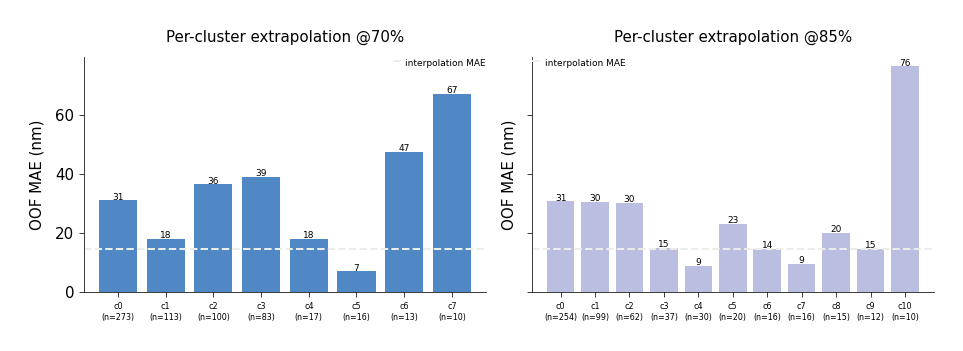

In [8]:
fig,ax=plt.subplots(1,2,figsize=(13,4.5),sharey=True)
for col,(tag,oof,clab) in enumerate([("@70%",oof_g70,clab70),("@85%",oof_g85,clab85)]):
    pc=per_cluster(oof,clab); a=ax[col]
    xs=[f"c{cid}\n(n={n})" for cid,n,_,_,_ in pc]; ys=[mae for _,_,mae,_,_ in pc]
    b=a.bar(xs,ys,color=apc_c.aegean if col==0 else apc_c.wish)
    a.axhline(summary[SCHEMES[0][0]]["m"]["mae"],ls="--",color=apc_c.gray,label="interpolation MAE")
    for r,v in zip(b,ys): a.text(r.get_x()+r.get_width()/2,v+0.5,f"{v:.0f}",ha="center",fontsize=9)
    a.set_title(f"Per-cluster extrapolation {tag}"); a.set_ylabel("OOF MAE (nm)"); a.legend(fontsize=9)
    a.tick_params(axis="x",labelsize=8)
plt.tight_layout(); plt.show()


## 6. OOF parity — predicted vs true peak

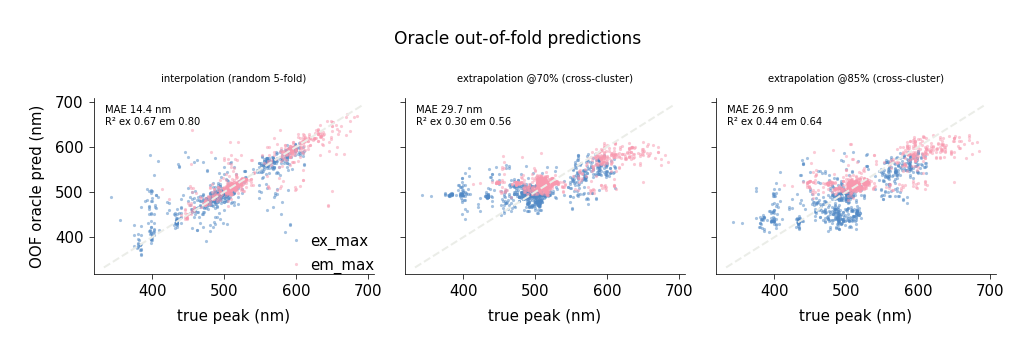

In [9]:
lo=float(min(peaks.min(),peaks.min()))-10; hi=float(peaks.max())+10
fig,axes=plt.subplots(1,3,figsize=(14,4.4),sharex=True,sharey=True)
for col,(name,oof,fid,_) in enumerate(SCHEMES):
    a=axes[col]; a.plot([lo,hi],[lo,hi],ls="--",color=apc_c.gray)
    a.scatter(peaks[:,0],oof[:,0],s=10,color=apc_c.aegean,alpha=0.5,label="ex_max")
    a.scatter(peaks[:,1],oof[:,1],s=10,color=apc_c.rose,alpha=0.5,label="em_max")
    m=metrics(oof,peaks)
    a.text(0.04,0.96,f"MAE {m['mae']:.1f} nm\nR² ex {m['r2_ex']:.2f} em {m['r2_em']:.2f}",
           transform=a.transAxes,va="top",fontsize=10,bbox=dict(boxstyle="round,pad=0.2",fc="white",ec="none"))
    a.set_title(name,fontsize=10); a.set_xlabel("true peak (nm)")
axes[0].set_ylabel("OOF oracle pred (nm)"); axes[0].legend(loc="lower right")
plt.suptitle("Oracle out-of-fold predictions"); plt.tight_layout(); plt.show()


## 7. Interpretation

- **Only the evaluation protocol changed** — the oracle architecture (`cnn-concatstd-d1`), loss,
  and hyperparameters match the pipeline; no existing weight/notebook/`peak_models.py` was touched.
  CV models are transient (cached predictions only).
- The **interpolation** baseline (random 5-fold) is the optimistic number: a test protein's near
  homologs are usually in training. Both **cross-cluster** schemes remove that crutch, so their MAE
  is the honest estimate of predicting **novel sequence families** — the setting the design loop
  actually operates in.
- Reading the two thresholds: **@70%** withholds whole lineages (hardest — pure family
  extrapolation); **@85%** withholds only near-duplicate sub-families (easier — the model may still
  see the broader lineage). The gap between them shows how quickly accuracy degrades as the training
  set's nearest neighbour to a query gets more distant.
- The **per-cluster** table localises the difficulty: large, spectrally-typical lineages extrapolate
  far better than small or spectrally-shifted ones — useful for deciding which target regions of
  `(ex_max, em_max)` the oracle can be trusted to score during design.
- Because grouped CV averages over all folds, these mean ± std numbers are far more stable than the
  single-split estimates and are the recommended yardstick going forward.
